# Statistical associations with eddy tilt direction

This notebook asks which surface and environmental feature groups have stable associations with **circular tilt direction**, independently for AE and CE. Direction is analysed only for tilt magnitude ≥5 km.

For scalability, two clustered GEE models estimate the eastward and northward components of the unit tilt vector. Their predictions are recombined into direction and resultant concentration. This respects angular wrap-around and repeated eddy-days, but it is not a fully joint projected-normal likelihood; the strongest findings can later be confirmed with a formal circular mixed model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels
import patsy

import seacofs_tilt_tools as tilt
import ml_subsurface_tools as ml

pd.set_option("display.max_columns", 80)
plt.rcParams["figure.dpi"] = 120
GRID_ROTATION_DEG = 20.0
DIRECTION_MIN_TILT_KM = 5.0
RUN_THRESHOLD_SENSITIVITY = False
print("statsmodels", statsmodels.__version__, "patsy", patsy.__version__)

statsmodels 0.14.6 patsy 1.0.2


## 1. Predeclared hypotheses

- CE direction is biased toward the raw PV-gradient bearing; AE is biased toward the opposite bearing, but neither is expected to be perfectly aligned.
- PV unit direction components contribute beyond PV magnitude.
- Propagation may encode EAC pathway rather than a direct daily dynamical association; within-eddy and between-eddy effects must therefore be distinguished.
- Ellipse orientation may contribute through its doubled-angle geographic encoding.
- Beta, `Rc`, `Omega`, and bathymetry may shift the directional distribution through nonlinear associations.

In [2]:
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, df_tilt = tilt.load_tilt_tables(paths)
df_vert = tilt.load_vert(paths)
max_depth = (df_vert.groupby(["Eddy", "Day"], as_index=False)["Depth"]
             .max().rename(columns={"Depth": "max_profile_depth"}))
df_eddies = df_eddies.merge(max_depth, on=["Eddy", "Day"], how="inner")
df_eddies = df_eddies[df_eddies["max_profile_depth"] > 850].copy()
df_eddies = tilt.add_pv_gradient_terms(df_eddies, grid, core_mean=True)
model_df = ml.prepare_modelling_table(df_eddies, grid_rotation_deg=GRID_ROTATION_DEG)
model_df = model_df[model_df["TiltDis"] >= DIRECTION_MIN_TILT_KM].copy()
polarity_data = {cyc: model_df[model_df["Cyc"] == cyc].copy() for cyc in ("AE", "CE")}
display(pd.DataFrame({cyc: {"rows": len(x), "eddies": x.Eddy.nunique()}
                      for cyc, x in polarity_data.items()}).T)

,rows,eddies
AE,35095,1279
CE,35263,1459


## 2. Direct circular description relative to PV

The expected reference is raw PV for CE and PV+180° for AE. Circular mean offset indicates systematic rotation from that reference; resultant length ranges from 0 (dispersed) to 1 (concentrated). Eddy-level summaries prevent long tracks dominating.

AE


,mean_delta_PV_deg,PV_alignment_concentration
count,1279.000,1279.000
mean,5.173,0.633
std,102.129,0.271
min,-179.798,0.004
25%,-83.238,0.407
50%,15.453,0.657
75%,91.824,0.886
max,179.594,1.000


CE


,mean_delta_PV_deg,PV_alignment_concentration
count,1459.000,1459.000
mean,-13.002,0.665
std,85.927,0.258
min,-179.479,0.038
25%,-72.351,0.467
50%,-14.727,0.697
75%,37.358,0.904
max,179.756,1.000


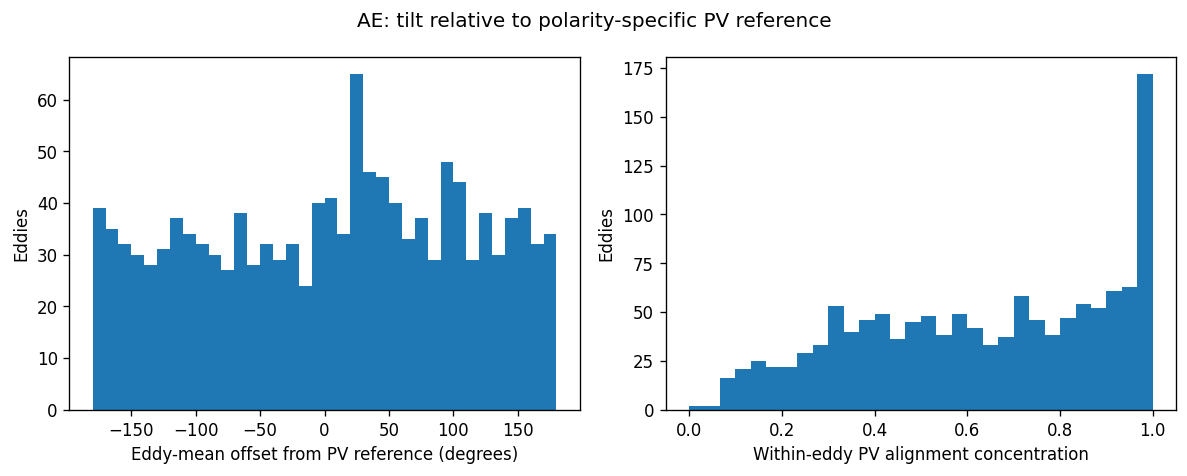

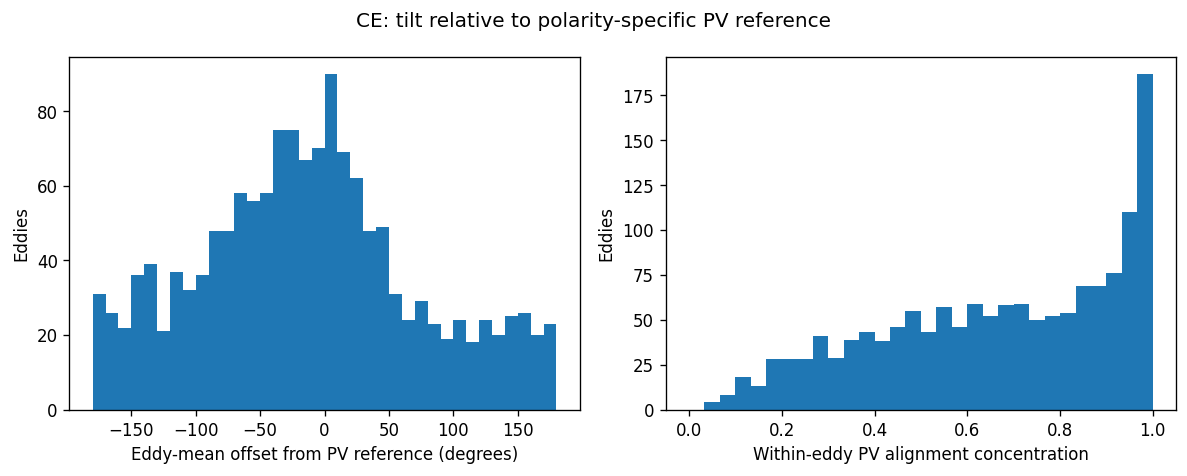

In [3]:
pv_relative = {}
for cyc, part in polarity_data.items():
    summary = ml.pv_relative_direction_summary(part)
    pv_relative[cyc] = summary
    print(cyc)
    display(summary[["mean_delta_PV_deg", "PV_alignment_concentration"]].describe().round(3))
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(summary["mean_delta_PV_deg"], bins=np.arange(-180, 185, 10))
    axes[0].set(xlabel="Eddy-mean offset from PV reference (degrees)", ylabel="Eddies")
    axes[1].hist(summary["PV_alignment_concentration"], bins=np.linspace(0, 1, 31))
    axes[1].set(xlabel="Within-eddy PV alignment concentration", ylabel="Eddies")
    fig.suptitle(f"{cyc}: tilt relative to polarity-specific PV reference")
    fig.tight_layout()

## 3. Within-eddy and between-eddy directional predictors

Between terms compare characteristic eddy pathways/structures. Within terms test whether a daily change within the same eddy accompanies a directional change. PV and ellipse directions remain in their circular component encodings.

In [4]:
association_data = {}
association_scaling = {}
for cyc, part in polarity_data.items():
    association_data[cyc], association_scaling[cyc] = ml.prepare_association_table(part)

## 4. Clustered circular-component association models

Separate east/north GEE fits use identical nonlinear terms and cluster-robust eddy uncertainty. The joint table reports whether a feature group is associated with either component; practical importance must also be checked through direction/concentration curves and the nested predictive ablation.

In [5]:
direction_gee = {}
direction_fit_data = {}
for cyc in ("AE", "CE"):
    print(f"Fitting {cyc} direction GEE pair...")
    results, common_index = ml.fit_direction_gee(association_data[cyc], covariance="exchangeable")
    direction_gee[cyc] = results
    direction_fit_data[cyc] = association_data[cyc].loc[common_index].copy()
    display(ml.direction_group_wald_table(results).round(4))

Fitting AE direction GEE pair...


,east_parameters_tested,east_wald_statistic,east_p_value,north_parameters_tested,north_wald_statistic,north_p_value
group,,,,,,
PV,12,38.9970,0.0001,12,10.2636,0.5928
beta,10,35.7321,0.0001,10,69.3828,0.0000
ellipse,2,104.7177,0.0000,2,62.8794,0.0000
environment,22,718.5325,0.0000,22,177.7230,0.0000
propagation,4,684.2612,0.0000,4,503.2718,0.0000
structure,22,207.6622,0.0000,22,145.0255,0.0000


Fitting CE direction GEE pair...


,east_parameters_tested,east_wald_statistic,east_p_value,north_parameters_tested,north_wald_statistic,north_p_value
group,,,,,,
PV,12,102.7023,0.0,12,89.9700,0.0
beta,10,70.7855,0.0,10,95.6032,0.0
ellipse,2,22.7163,0.0,2,21.9408,0.0
environment,22,844.3751,0.0,22,207.4049,0.0
propagation,4,610.2263,0.0,4,758.6532,0.0
structure,22,182.8348,0.0,22,122.4848,0.0


## 5. Direction and concentration effect curves

Direction shows how the conditional mean bearing changes. Concentration shows how strongly the component predictions define a preferred direction; a direction curve is not scientifically meaningful where concentration is close to zero.

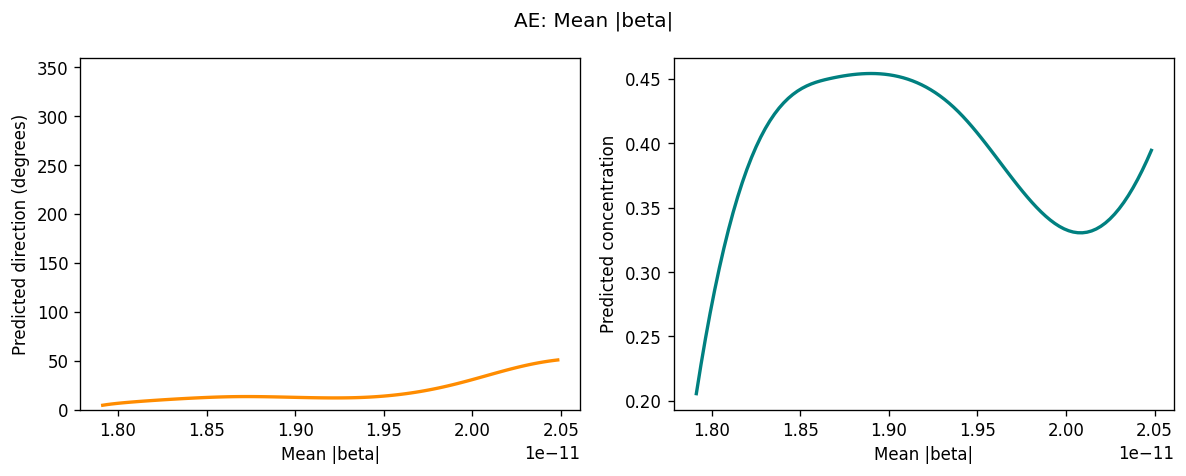

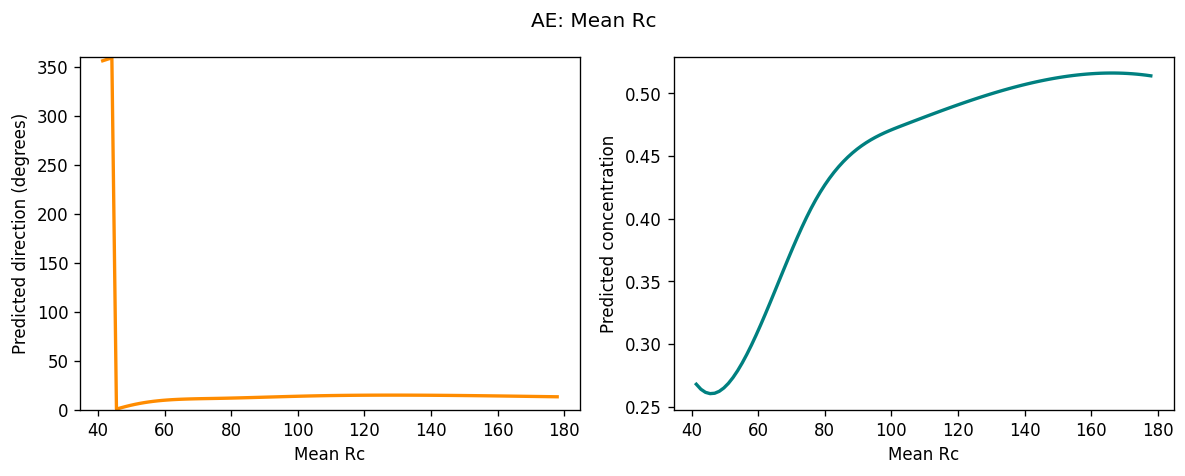

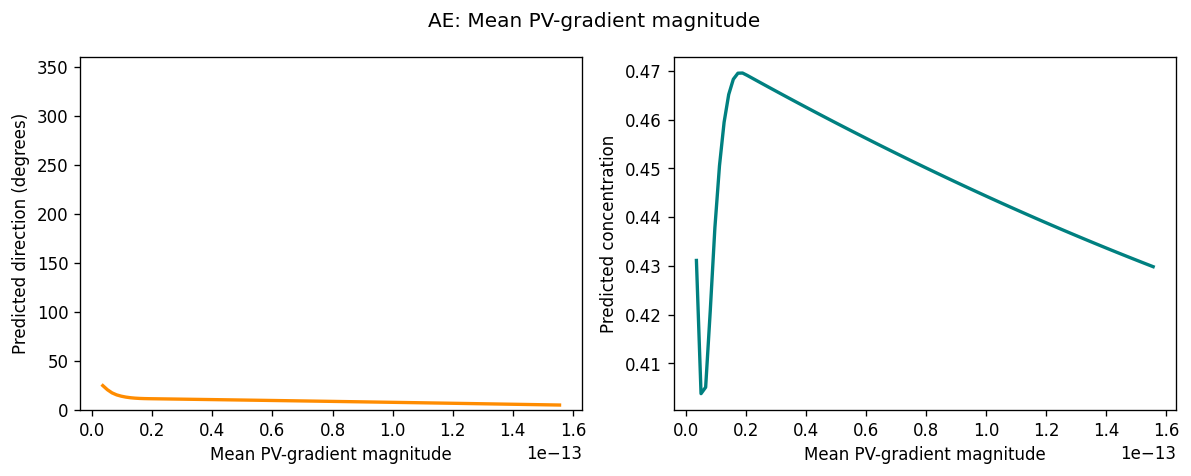

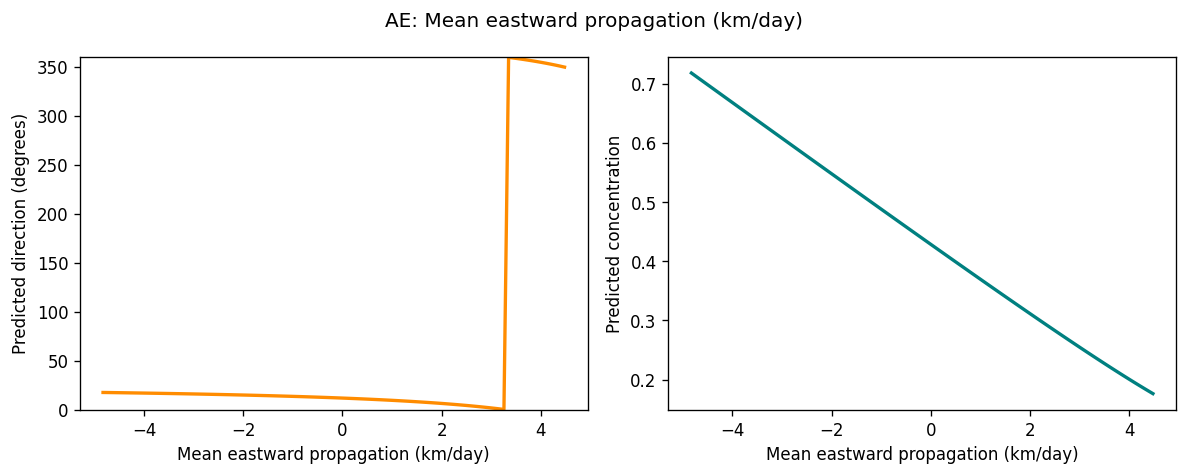

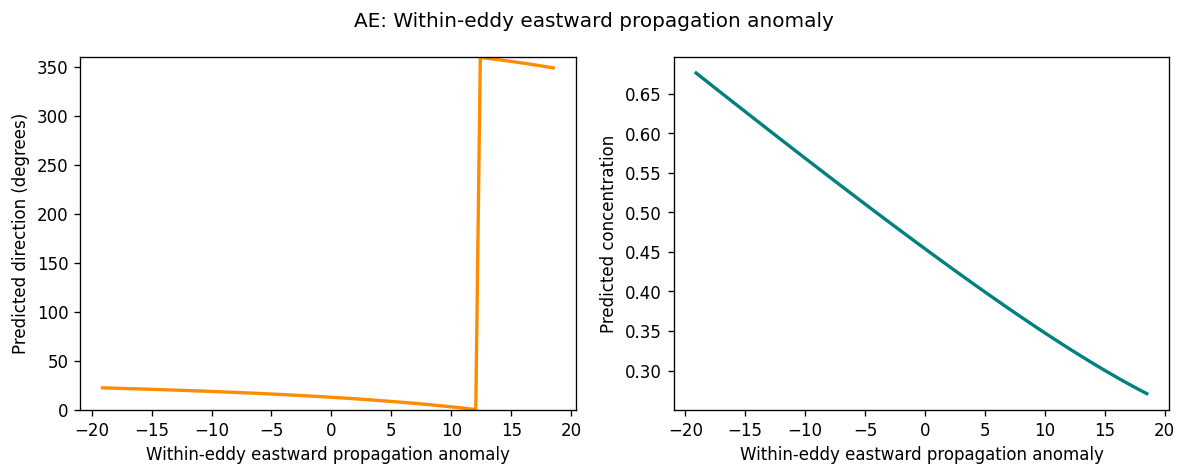

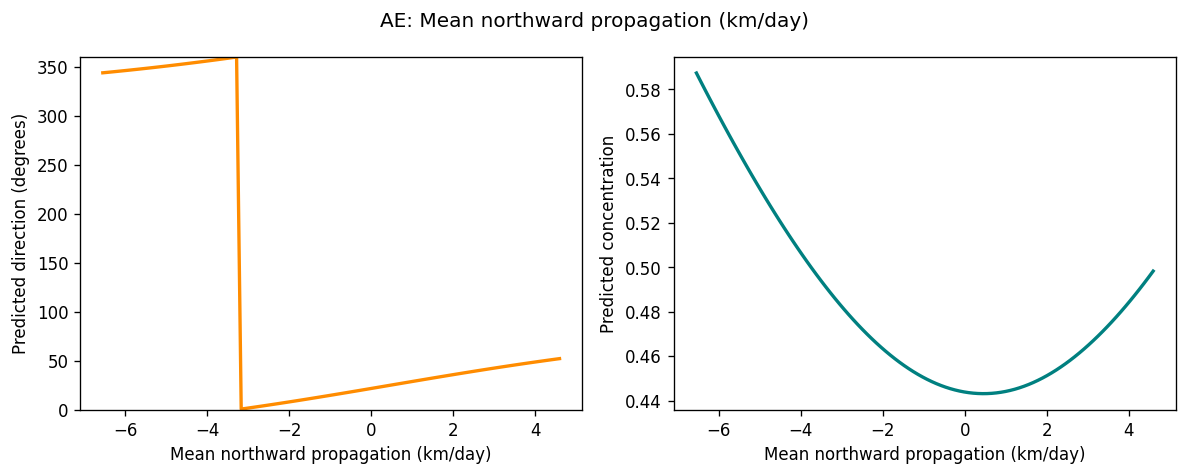

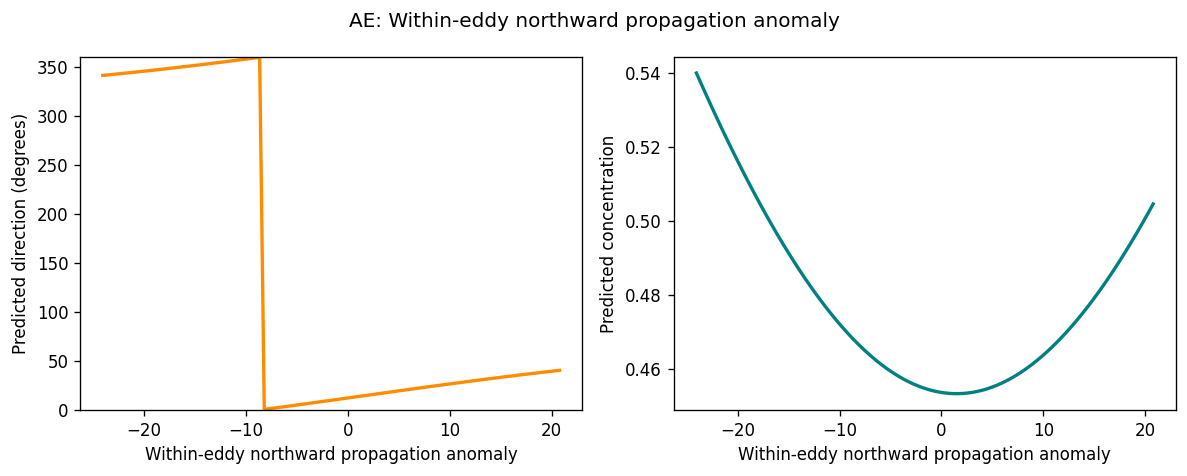

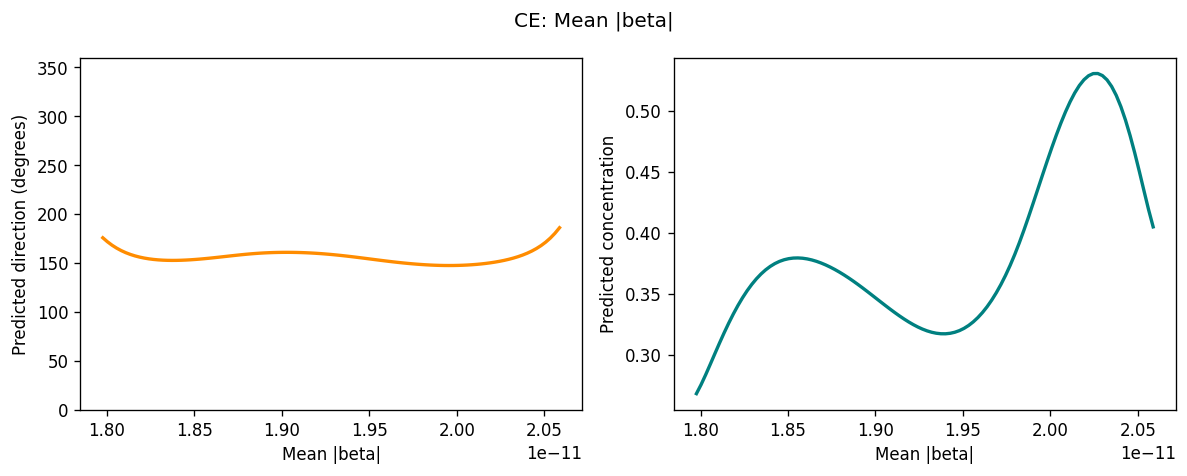

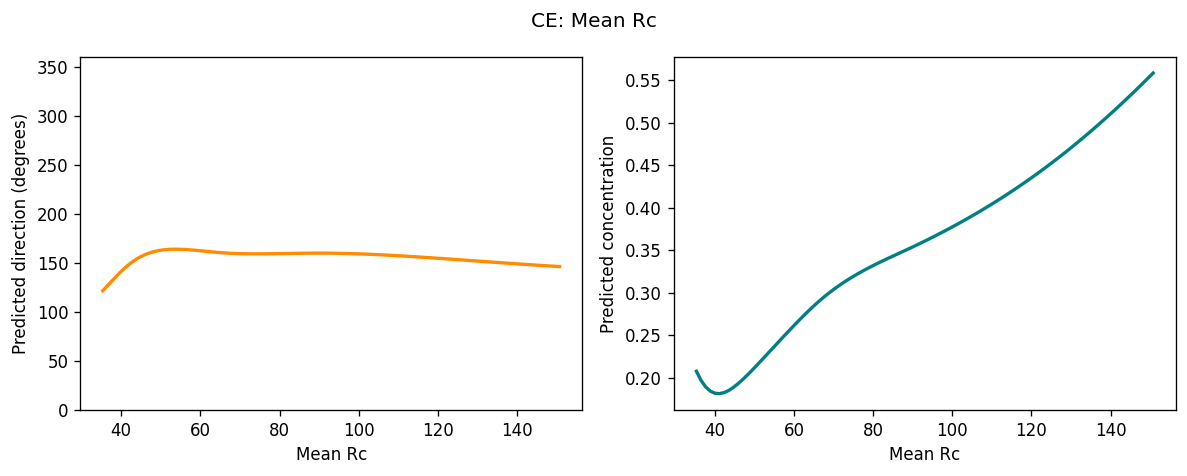

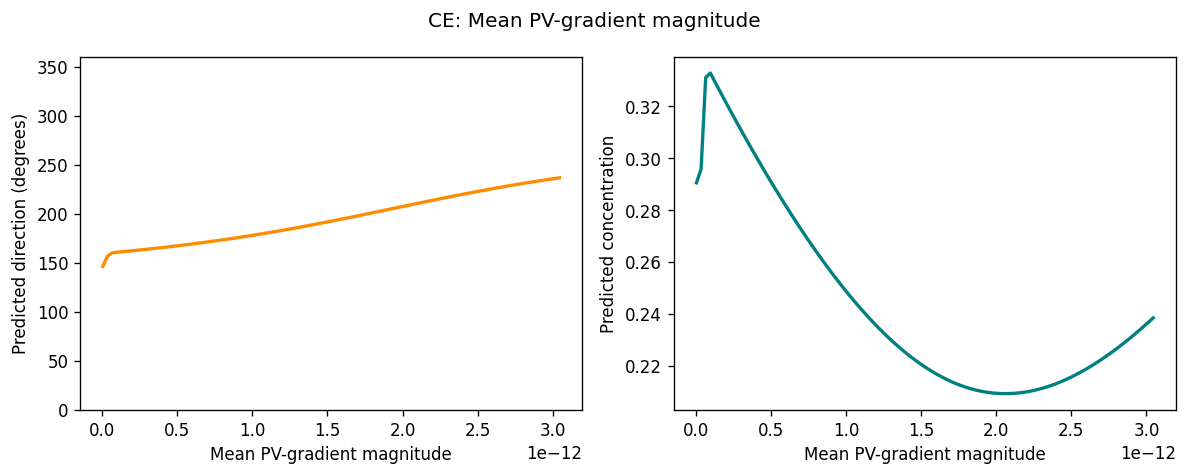

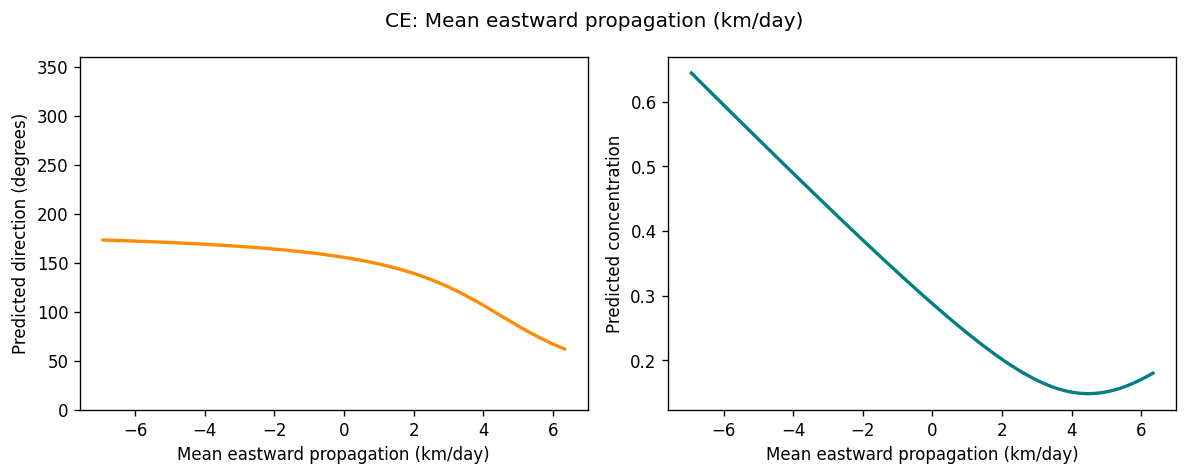

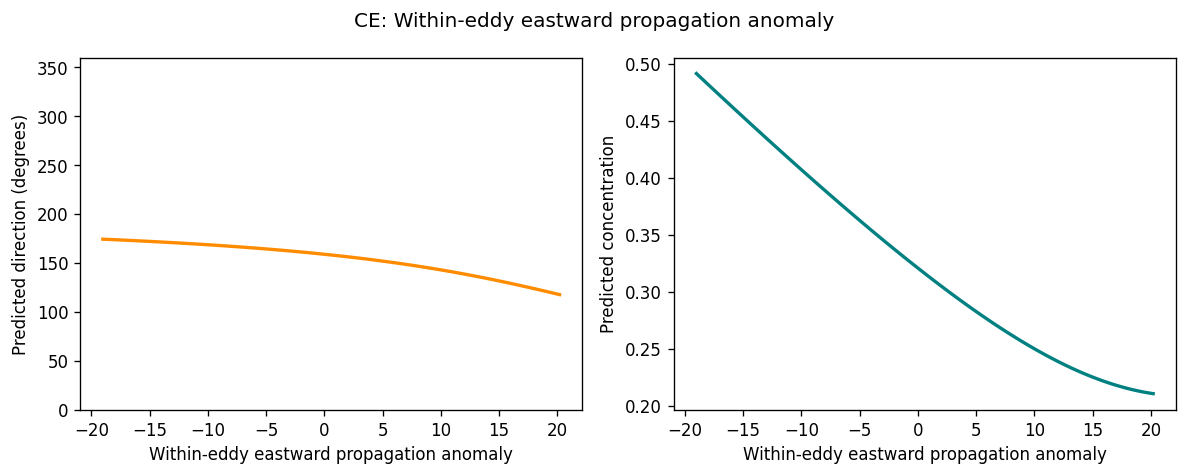

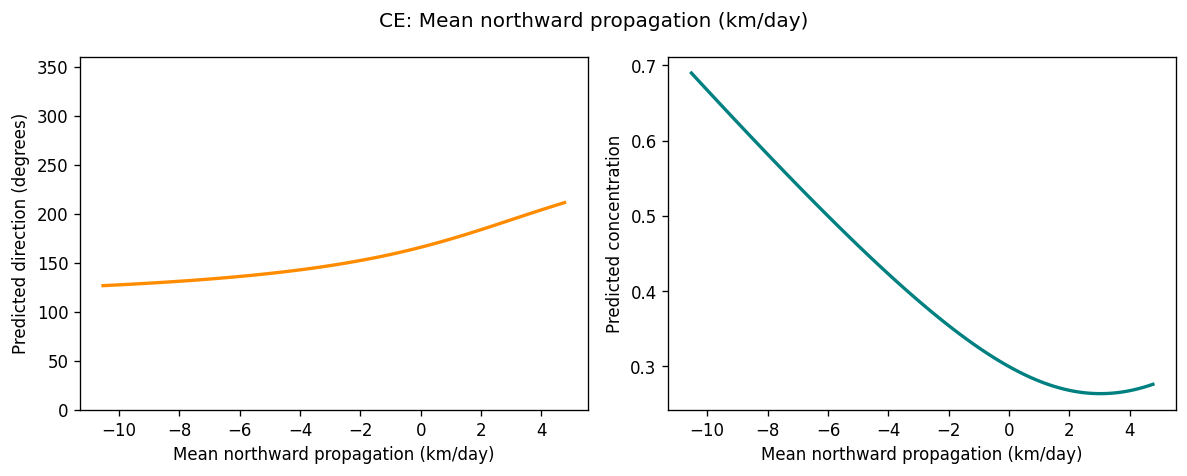

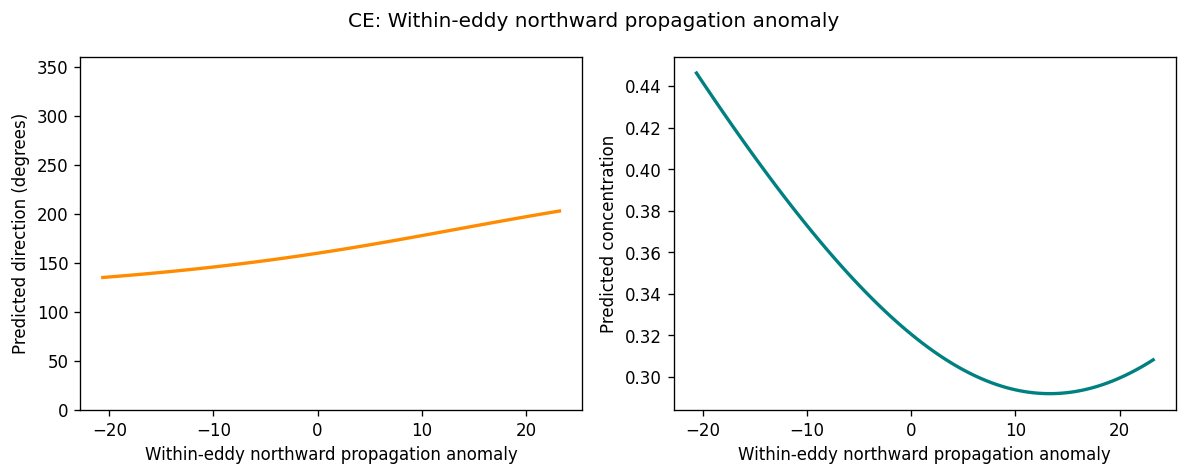

In [6]:
direction_curves = {}
curve_features = {
    "abs_beta_between_z": "Mean |beta|",
    "Rc_between_z": "Mean Rc",
    "PV_grad_mag_between_z": "Mean PV-gradient magnitude",
    "prop_east_km_day_between_z": "Mean eastward propagation (km/day)",
    "prop_east_km_day_within_z": "Within-eddy eastward propagation anomaly",
    "prop_north_km_day_between_z": "Mean northward propagation (km/day)",
    "prop_north_km_day_within_z": "Within-eddy northward propagation anomaly",
}
for cyc in ("AE", "CE"):
    direction_curves[cyc] = {}
    for feature, label in curve_features.items():
        curve = ml.direction_effect_curve(
            direction_gee[cyc], direction_fit_data[cyc], feature,
            scaling=association_scaling[cyc],
        )
        direction_curves[cyc][feature] = curve
        ml.plot_direction_effect_curve(curve, xlabel=label, title=f"{cyc}: {label}")

## 6. PV and ellipse directional terms

PV unit and ellipse doubled-angle components cannot be interpreted through a one-dimensional component curve. Inspect their joint robust tests and compare fitted versus observed relative-angle distributions. The ML `full` versus `without_PV` and `without_ellipse` results provide the corresponding out-of-sample effect-size evidence.

In [7]:
component_terms = ["PV_grad_unit_east", "PV_grad_unit_north",
                   "ellipse_major_cos2", "ellipse_major_sin2"]
for cyc, results in direction_gee.items():
    rows = []
    for component, result in results.items():
        table = pd.DataFrame({"coefficient": result.params, "SE": result.bse, "p_value": result.pvalues})
        table = table.loc[table.index.intersection(component_terms)].assign(response_component=component)
        rows.append(table)
    print(cyc)
    display(pd.concat(rows).round(4))

AE


,coefficient,SE,p_value,response_component
ellipse_major_cos2,-0.1407,0.0138,0.0000,east
ellipse_major_sin2,-0.0022,0.0121,0.8534,east
PV_grad_unit_east,0.0562,0.0164,0.0006,east
PV_grad_unit_north,-0.0332,0.0171,0.0522,east
ellipse_major_cos2,0.0077,0.0125,0.5380,north
ellipse_major_sin2,-0.0973,0.0123,0.0000,north
PV_grad_unit_east,0.0012,0.0162,0.9413,north
PV_grad_unit_north,0.0147,0.0189,0.4361,north


CE


,coefficient,SE,p_value,response_component
ellipse_major_cos2,0.0566,0.0126,0.0000,east
ellipse_major_sin2,0.0178,0.0126,0.1584,east
PV_grad_unit_east,0.1126,0.0198,0.0000,east
PV_grad_unit_north,-0.0654,0.0195,0.0008,east
ellipse_major_cos2,0.0228,0.0117,0.0519,north
ellipse_major_sin2,0.0474,0.0117,0.0001,north
PV_grad_unit_east,0.0441,0.0141,0.0018,north
PV_grad_unit_north,0.1116,0.0179,0.0000,north


## 7. Threshold and covariance sensitivity

Working-independence fits are run by default. Setting `RUN_THRESHOLD_SENSITIVITY=True` additionally refits the models above 10 and 20 km. Stable directional associations should retain compatible group conclusions as direction becomes better defined.

In [8]:
for cyc in ("AE", "CE"):
    independent, _ = ml.fit_direction_gee(association_data[cyc], covariance="independence")
    print(cyc, "working-independence sensitivity")
    display(ml.direction_group_wald_table(independent).round(4))

if RUN_THRESHOLD_SENSITIVITY:
    for threshold in (10.0, 20.0):
        for cyc, original in polarity_data.items():
            subset = original[original["TiltDis"] >= threshold].copy()
            prepared, _ = ml.prepare_association_table(subset)
            results, _ = ml.fit_direction_gee(prepared, covariance="exchangeable")
            print(cyc, f"TiltDis >= {threshold:g} km")
            display(ml.direction_group_wald_table(results).round(4))

AE working-independence sensitivity


,east_parameters_tested,east_wald_statistic,east_p_value,north_parameters_tested,north_wald_statistic,north_p_value
group,,,,,,
PV,12,44.6125,0.0,12,19.5265,0.0766
beta,10,43.9638,0.0,10,76.5344,0.0000
ellipse,2,79.0042,0.0,2,56.9028,0.0000
environment,22,870.0957,0.0,22,219.9668,0.0000
propagation,4,836.3610,0.0,4,576.5375,0.0000
structure,22,234.1825,0.0,22,140.4515,0.0000


CE working-independence sensitivity


,east_parameters_tested,east_wald_statistic,east_p_value,north_parameters_tested,north_wald_statistic,north_p_value
group,,,,,,
PV,12,208.1958,0.0,12,147.5505,0.0
beta,10,67.0679,0.0,10,104.5278,0.0
ellipse,2,20.0088,0.0,2,29.6910,0.0
environment,22,921.1507,0.0,22,200.8311,0.0
propagation,4,677.3045,0.0,4,878.2225,0.0
structure,22,136.9818,0.0,22,150.0116,0.0


## 8. Reporting template

For AE and CE separately report: (1) the eddy-level PV-relative offset and concentration distribution; (2) joint east/north feature-group tests; (3) between-eddy versus within-eddy propagation curves; (4) curve concentration wherever direction is interpreted; (5) compatibility under working-independence and magnitude-threshold sensitivity; and (6) nested-ML angular-error change after removing the same group.

A poor propagation-direction baseline does not prove propagation is irrelevant: components can still encode pathway or interact with other covariates. A group should be called stably associated only when statistical, predictive, threshold, and spatial evidence agree.